In [3]:
import pandas as pd
df = pd.read_csv("samadult.csv")
df.shape  

(25417, 742)

In [13]:
df.memory_usage(deep=True).sum() / 1024**2  

np.float64(143.88603591918945)

In [15]:
df.dtypes.value_counts()


float64    559
int64      183
Name: count, dtype: int64

In [16]:
df.nunique().describe()

count      742.000000
mean        76.873315
std       1067.757788
min          1.000000
25%          4.000000
50%          5.000000
75%         10.000000
max      25021.000000
dtype: float64

In [31]:
df["AMIGR"].value_counts(dropna=False)

AMIGR
2    21533
1     3870
7       10
9        4
Name: count, dtype: int64

In [32]:
df["BMI"].value_counts(dropna=False).head(10)

BMI
9999    788
2585    203
2508    190
2439    188
2663    162
2581    161
2662    157
2741    155
2434    150
2746    149
Name: count, dtype: int64

In [33]:
df[["AMIGR","HYPEV","AGE_P","BMI","DEP_1","ANX_1"]].nunique()

AMIGR       4
HYPEV       4
AGE_P      68
BMI      2035
DEP_1       8
ANX_1       8
dtype: int64

In [34]:
def top_values(s, k=3):
    vc = s.value_counts(dropna=False).head(k)
    return "; ".join([f"{idx}:{cnt}" for idx, cnt in vc.items()])

for c in ["AMIGR","HYPEV","DEP_1","AGE_P","BMI"]:
    print(c, "→ unique:", df[c].nunique(),
          "missing rate:", round(df[c].isna().mean(),3),
          "top values:", top_values(df[c]))

AMIGR → unique: 4 missing rate: 0.0 top values: 2:21533; 1:3870; 7:10
HYPEV → unique: 4 missing rate: 0.0 top values: 2:16153; 1:9217; 9:26
DEP_1 → unique: 8 missing rate: 0.0 top values: 5:14230; 4:6250; 3:1543
AGE_P → unique: 68 missing rate: 0.0 top values: 85:865; 62:502; 66:486
BMI → unique: 2035 missing rate: 0.0 top values: 9999:788; 2585:203; 2508:190


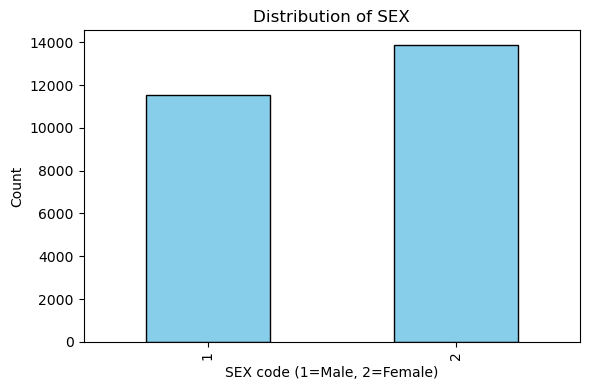

In [37]:
plt.figure(figsize=(6,4))
df["SEX"].value_counts().sort_index().plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution of SEX")
plt.xlabel("SEX code (1=Male, 2=Female)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Figure3_SEX.png", dpi=150)
plt.show()

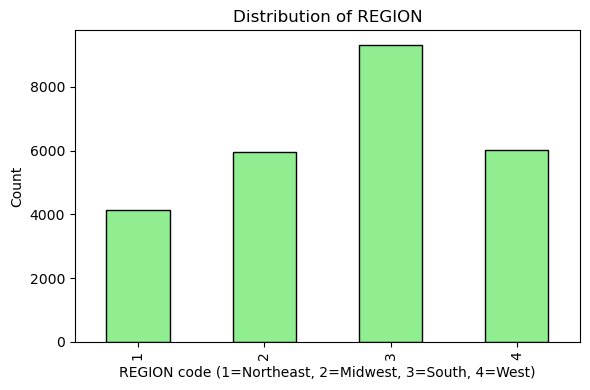

In [38]:
plt.figure(figsize=(6,4))
df["REGION"].value_counts().sort_index().plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Distribution of REGION")
plt.xlabel("REGION code (1=Northeast, 2=Midwest, 3=South, 4=West)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Figure4_REGION.png", dpi=150)
plt.show()

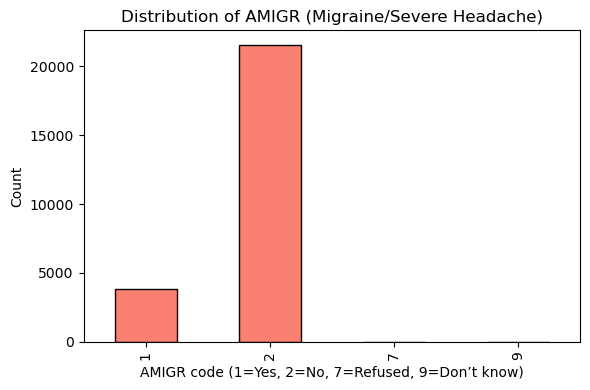

In [39]:
plt.figure(figsize=(6,4))
df["AMIGR"].value_counts(dropna=False).sort_index().plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Distribution of AMIGR (Migraine/Severe Headache)")
plt.xlabel("AMIGR code (1=Yes, 2=No, 7=Refused, 9=Don’t know)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Figure5_AMIGR.png", dpi=150)
plt.show()

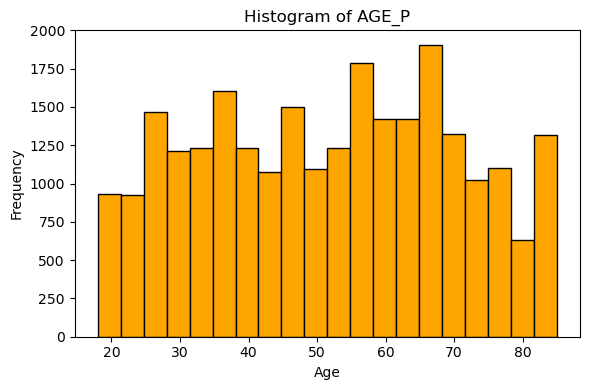

In [41]:
plt.figure(figsize=(6,4))
df["AGE_P"].plot(kind="hist", bins=20, color="orange", edgecolor="black")
plt.title("Histogram of AGE_P")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Figure6_AGEP.png", dpi=150)
plt.show()

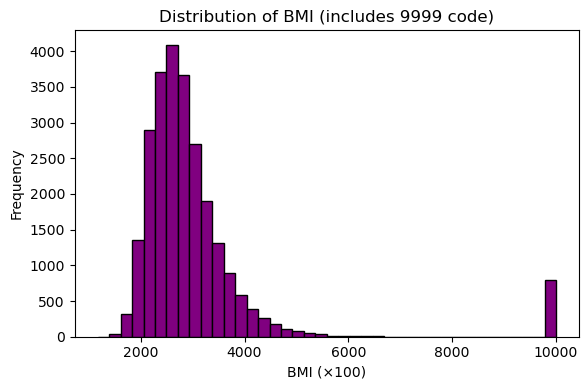

In [42]:
plt.figure(figsize=(6,4))
df["BMI"].plot(kind="hist", bins=40, color="purple", edgecolor="black")
plt.title("Distribution of BMI (includes 9999 code)")
plt.xlabel("BMI (×100)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Figure7_BMI.png", dpi=150)
plt.show()

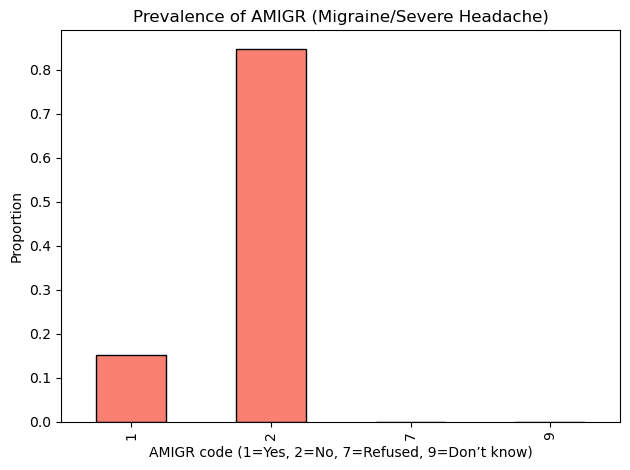

In [69]:
df["AMIGR"].value_counts(normalize=True).sort_index().plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Prevalence of AMIGR (Migraine/Severe Headache)")
plt.xlabel("AMIGR code (1=Yes, 2=No, 7=Refused, 9=Don’t know)")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

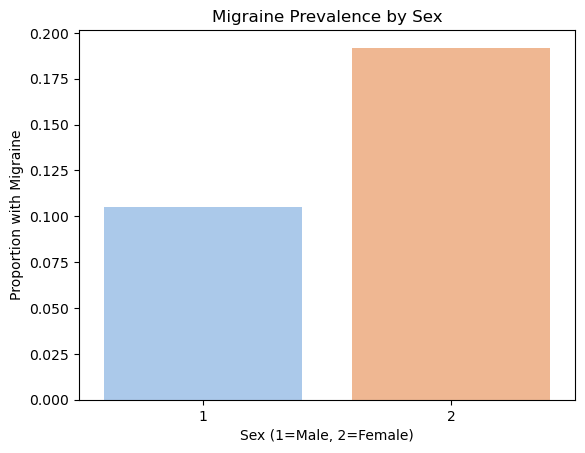

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

df_clean = df.replace({7: None, 8: None, 9: None})

sns.barplot(
    x="SEX",
    y="AMIGR",
    hue="SEX",          
    data=df_clean,
    estimator=lambda x: (x==1).mean(),
    errorbar=None,
    palette="pastel",
    legend=False        
)

plt.title("Migraine Prevalence by Sex")
plt.xlabel("Sex (1=Male, 2=Female)")
plt.ylabel("Proportion with Migraine")
plt.show()

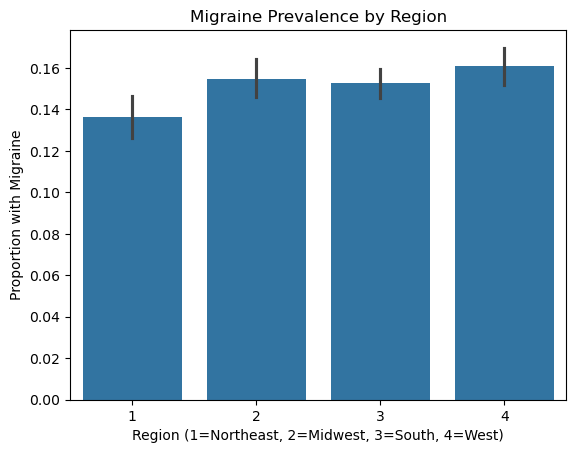

In [48]:
sns.barplot(x="REGION", y="AMIGR", data=df.replace({7:None, 8:None, 9:None}), estimator=lambda x: (x==1).mean())
plt.title("Migraine Prevalence by Region")
plt.xlabel("Region (1=Northeast, 2=Midwest, 3=South, 4=West)")
plt.ylabel("Proportion with Migraine")
plt.show()

/var/folders/ck/kywdwpdd2ll7xhvw52kgy4780000gn/T/ipykernel_82235/2665036623.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


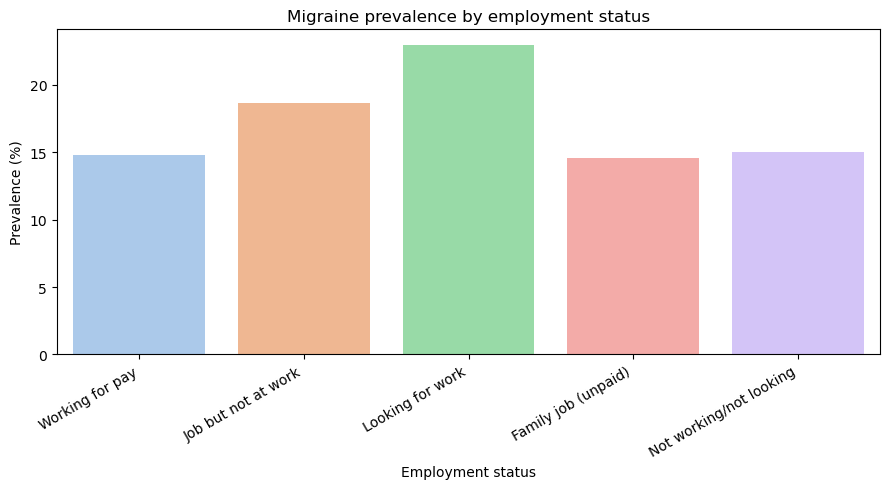

In [58]:
labels = {
    1: "Working for pay",
    2: "Job but not at work",
    3: "Looking for work",
    4: "Family job (unpaid)",
    5: "Not working/not looking"
}

plt.figure(figsize=(9,5))
sns.barplot(
    data=employment_prev,
    x="DOINGLWA",
    y="Migraine Prevalence (%)",
    palette="pastel"
)
plt.title("Migraine prevalence by employment status")
plt.xlabel("Employment status")
plt.ylabel("Prevalence (%)")

plt.xticks(
    ticks=range(len(labels)), 
    labels=list(labels.values()), 
    rotation=30, ha="right"
)

plt.tight_layout()
plt.show()


/var/folders/ck/kywdwpdd2ll7xhvw52kgy4780000gn/T/ipykernel_82235/29982430.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


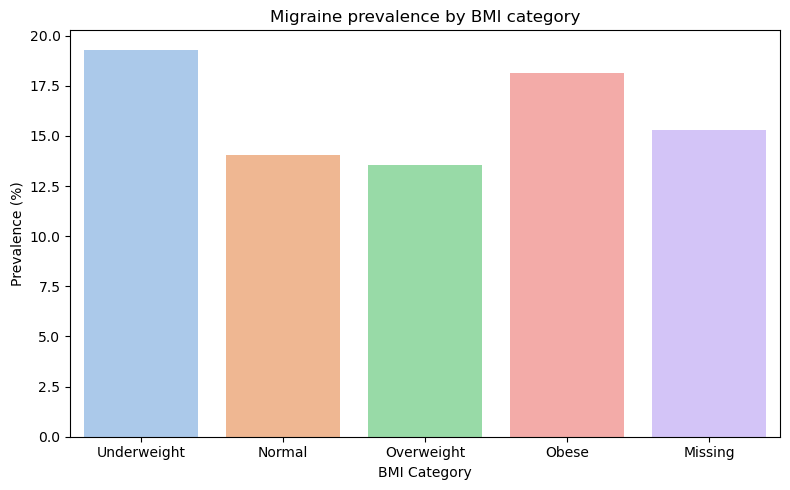

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_clean = df[df["AMIGR"].isin([1,2])].copy()

df_clean["BMI"] = df_clean["BMI"].replace(9999, pd.NA) / 100.0  


def bmi_category(bmi):
    if pd.isna(bmi):
        return "Missing"
    elif bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df_clean["BMI_CAT"] = df_clean["BMI"].apply(bmi_category)

bmi_prev = (
    df_clean.groupby("BMI_CAT")["AMIGR"]
    .apply(lambda x: (x==1).mean()*100)
    .reset_index(name="Migraine Prevalence (%)")
)

order = ["Underweight","Normal","Overweight","Obese","Missing"]

plt.figure(figsize=(8,5))
sns.barplot(
    data=bmi_prev,
    x="BMI_CAT",
    y="Migraine Prevalence (%)",
    order=order,
    palette="pastel"
)
plt.title("Migraine prevalence by BMI category")
plt.xlabel("BMI Category")
plt.ylabel("Prevalence (%)")
plt.tight_layout()
plt.show()


  SLEEP_CAT  Migraine Prevalence (%)
0       <6h                27.784431
1        6h                18.410338
2      7–8h                12.027586
3     9–10h                13.488902
4      ≥11h                16.304348


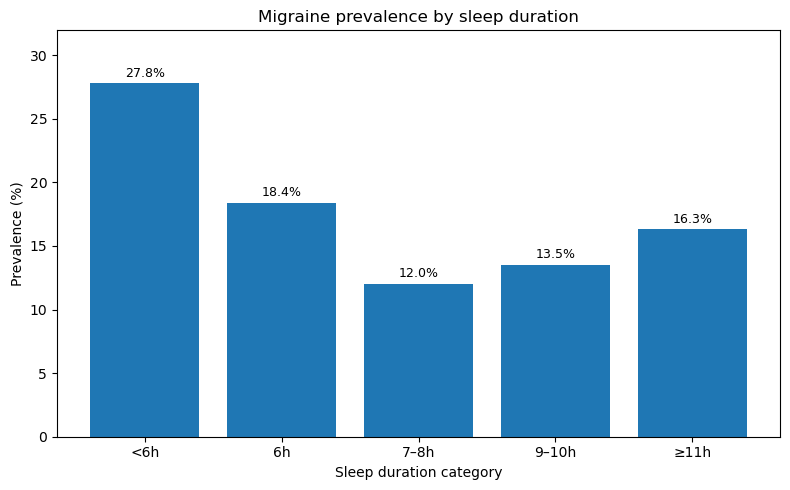

In [62]:
import numpy as np
df_am = df[df["AMIGR"].isin([1,2])].copy()

sleep = df_am["ASISLEEP"].replace({97: np.nan, 98: np.nan, 99: np.nan})

def sleep_bucket(h):
    if pd.isna(h):
        return np.nan
    if h < 6:
        return "<6h"
    elif h == 6:
        return "6h"
    elif 7 <= h <= 8:
        return "7–8h"
    elif 9 <= h <= 10:
        return "9–10h"
    else:
        return "≥11h"

df_am["SLEEP_CAT"] = sleep.apply(sleep_bucket)

prev_tbl = (
    df_am.dropna(subset=["SLEEP_CAT"])
        .groupby("SLEEP_CAT")["AMIGR"]
        .apply(lambda x: (x==1).mean()*100)
        .reindex(["<6h","6h","7–8h","9–10h","≥11h"])
        .rename("Migraine Prevalence (%)")
        .reset_index()
)

prev_tbl.to_csv("Table_Sleep_Migraine_Prevalence.csv", index=False)
print(prev_tbl)

plt.figure(figsize=(8,5))
bars = plt.bar(prev_tbl["SLEEP_CAT"], prev_tbl["Migraine Prevalence (%)"])
plt.title("Migraine prevalence by sleep duration")
plt.xlabel("Sleep duration category")
plt.ylabel("Prevalence (%)")
plt.ylim(0, max(prev_tbl["Migraine Prevalence (%)"])*1.15)

for b, v in zip(bars, prev_tbl["Migraine Prevalence (%)"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height()+0.3, f"{v:.1f}%", 
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("Figure_Sleep_Migraine.png", dpi=150)
plt.show()


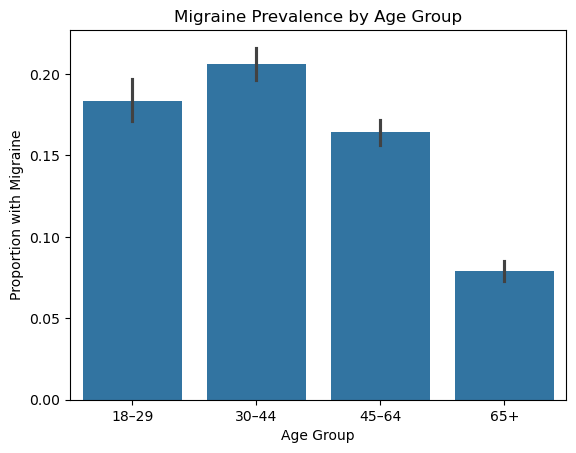

In [53]:
df["AGE_GROUP"] = pd.cut(df["AGE_P"], bins=[17,29,44,64,85], labels=["18–29","30–44","45–64","65+"])
sns.barplot(x="AGE_GROUP", y="AMIGR", data=df.replace({7:None, 8:None, 9:None}), estimator=lambda x: (x==1).mean())
plt.title("Migraine Prevalence by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion with Migraine")
plt.show()

/var/folders/ck/kywdwpdd2ll7xhvw52kgy4780000gn/T/ipykernel_82235/4069289998.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(["AGE_GROUP","SEX"])["AMIGR"]


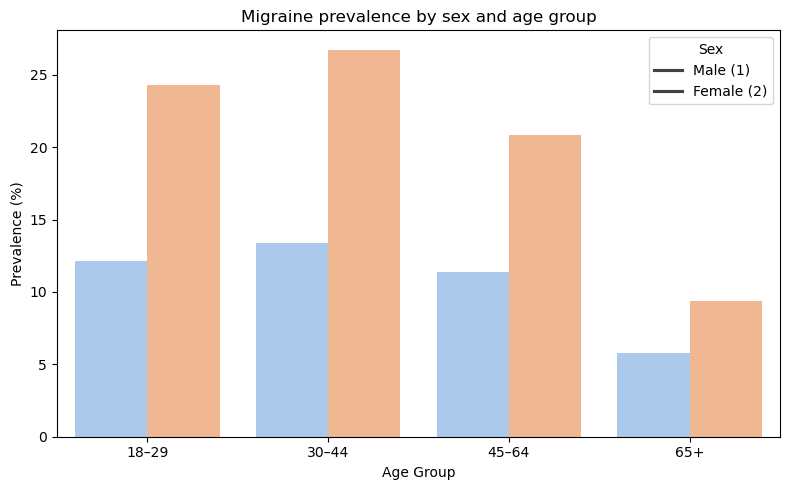

In [54]:
df_clean = df[df["AMIGR"].isin([1,2])].copy()

df_clean["AGE_GROUP"] = pd.cut(
    df_clean["AGE_P"],
    bins=[17,29,44,64,85],
    labels=["18–29","30–44","45–64","65+"]
)

prevalence = (
    df_clean.groupby(["AGE_GROUP","SEX"])["AMIGR"]
    .apply(lambda x: (x==1).mean()*100) 
    .reset_index(name="Migraine Prevalence (%)")
)


plt.figure(figsize=(8,5))
sns.barplot(
    data=prevalence,
    x="AGE_GROUP",
    y="Migraine Prevalence (%)",
    hue="SEX",
    palette="pastel"
)
plt.title("Migraine prevalence by sex and age group")
plt.xlabel("Age Group")
plt.ylabel("Prevalence (%)")
plt.legend(title="Sex", labels=["Male (1)","Female (2)"])
plt.tight_layout()
plt.show()

In [64]:
unique_counts = df.nunique().sort_values()
constant_vars = unique_counts[unique_counts==1]
print("Constant variables:", len(constant_vars))

Constant variables: 24


In [68]:
print(constant_vars.index.tolist())

['ALUNIT13', 'ALCHRC29', 'ALUNIT91', 'ALCHRC3', 'ALCHRC19', 'ALCHRC32', 'ALCHRC16', 'ALCHRC15', 'ALCHRC13', 'ALCHRC12', 'ALCHRC34', 'ALTIME13', 'ALUNIT29', 'ALCHRC10', 'ALDURB91', 'ALCHRC7', 'SRVY_YR', 'RECTYPE', 'ALCHRC9', 'ALCHRC91', 'ALDURB29', 'ACHRC14A', 'ALDURB13', 'ALCHRC8']


In [65]:
missing_counts = df.isna().sum()
missing_ratio = (missing_counts / len(df)) * 100
missing_summary = missing_ratio.sort_values(ascending=False).head(10)
print(missing_summary)

ALTIME91    99.992131
ALCHRC91    99.992131
ALDURA91    99.992131
ALUNIT91    99.992131
ALDURB91    99.992131
ALTIME29    99.988197
ALDURB29    99.988197
ALUNIT29    99.988197
ALDURA29    99.988197
ALCHRC29    99.988197
dtype: float64


In [66]:
print(df["AMIGR"].value_counts(dropna=False))
print(df["BMI"].value_counts(dropna=False).head())
print(df["ASISLEEP"].value_counts(dropna=False).head())

AMIGR
2    21533
1     3870
7       10
9        4
Name: count, dtype: int64
BMI
9999    788
2585    203
2508    190
2439    188
2663    162
Name: count, dtype: int64
ASISLEEP
8    7335
7    7171
6    5652
5    1687
9    1059
Name: count, dtype: int64


In [67]:

print("AGE_P:", df["AGE_P"].min(), df["AGE_P"].max())
print("ASISLEEP:", df["ASISLEEP"].min(), df["ASISLEEP"].max())
print("BMI:", df["BMI"].min(), df["BMI"].max())

AGE_P: 18 85
ASISLEEP: 1 99
BMI: 1171 9999
